# Часть 1. Прогнозирование рейтинга фильма (табличные данные, FCNN)

**Бизнес-задача.** Хотим прогнозировать зрительский рейтинг по его характеристикам. Это позволит нам:
- принимать решения о том, **какие фильмы покупать** в каталог;
- определять, **какой контент продвигать** на главной странице.

Данные: https://www.kaggle.com/datasets/willianoliveiragibin/10000-data-about-movies-1915-2023?select=data.csv

Content:
- movie_name: The title of the movie.
- year: The year of the movie's release.
- rating: IMDb user rating.
- metascore: Metascore rating.
- gross_income: Gross income of the movie.
- votes: Number of votes on IMDb.
- runtime: Duration of the movie in minutes.
- genre: Genre(s) of the movie.
- certificate: Certification or rating of the movie.
- description: A brief summary or plot of the movie.
- directors: Director(s) of the movie.
- stars: Main cast or actors of the movie.



In [1]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 
wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: smallberych (smallberych-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Загрузка данных

In [3]:
df = pd.read_csv('data.csv', index_col=0)


In [4]:
df.dtypes

,0
Movie Name,object
Year of Release,int64
Run Time in minutes,int64
Movie Rating,float64
Votes,int64
MetaScore,float64
Gross,float64
Genre,object
Certification,object
Director,object


In [5]:
df

,Movie Name,Year of Release,Run Time in minutes,Movie Rating,Votes,MetaScore,Gross,Genre,Certification,Director,Stars,Description
0,The Shawshank Redemption,1994,142,9.3,2804443,82.0,28340000.0,['Drama'],R,['Frank Darabont'],"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...","['Over', 'the', 'course', 'of', 'several', 'ye..."
1,The Godfather,1972,175,9.2,1954174,100.0,134970000.0,"['Crime', ' Drama']",R,['Francis Ford Coppola'],"['Marlon Brando', 'Al Pacino', 'James Caan', '...","['Don', 'Vito', 'Corleone,', 'head', 'of', 'a'..."
2,Ramayana: The Legend of Prince Rama,1993,135,9.2,12995,NaN,NaN,"['Animation', ' Action', ' Adventure']",PG,"['Ram Mohan', 'Yûgô Sakô', 'Koichi Saski']","['Arun Govil', 'Nikhil Kapoor', 'Edie Mirman',...","['An', 'anime', 'adaptation', 'of', 'the', 'Hi..."
3,The Chaos Class,1975,87,9.2,42231,NaN,NaN,"['Comedy', ' Drama']",NaN,['Ertem Egilmez'],"['Kemal Sunal', 'Münir Özkul', 'Halit Akçatepe...","['Lazy,', 'uneducated', 'students', 'share', '..."
4,The Dark Knight,2008,152,9.0,2786129,84.0,534860000.0,"['Action', ' Crime', ' Drama']",PG-13,['Christopher Nolan'],"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...","['When', 'the', 'menace', 'known', 'as', 'the'..."
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Golmaal Again,2017,140,4.9,10183,NaN,1010000.0,"['Action', ' Comedy', ' Fantasy']",Not Rated,['Rohit Shetty'],"['Ajay Devgn', 'Arshad Warsi', 'Tabu', 'Shreya...","['The', 'gang', 'encounters', 'with', 'some', ..."
9996,Not to Forget,2021,84,4.9,11191,NaN,NaN,['Drama'],NaN,['Valerio Zanoli'],"['Karen Grassle', 'Louis Gossett Jr.', ""Tatum ...","['After', 'a', 'lifetime', 'of', 'scams,', 'a'..."
9997,Housefull 3,2016,140,4.9,10308,NaN,1160000.0,"['Action', ' Comedy', ' Romance']",Not Rated,"['Sajid', 'Farhad Samji']","['Akshay Kumar', 'Abhishek Bachchan', 'Riteish...","['A', 'father', ""doesn't"", 'want', 'his', 'thr..."
9998,A.I. Rising,2018,85,4.9,11187,NaN,NaN,"['Drama', ' Romance', ' Sci-Fi']",R,['Lazar Bodroza'],"['Sebastian Cavazza', 'Stoya', 'Marusa Majer',...","['An', 'intimate', 'relationship', 'between', ..."


### Пропуски

In [6]:
df.isnull().sum()

,0
Movie Name,0
Year of Release,0
Run Time in minutes,0
Movie Rating,0
Votes,0
MetaScore,2026
Gross,2915
Genre,0
Certification,369
Director,0


Есть пропуски в доходах, метарейтинге, возрастном жанре

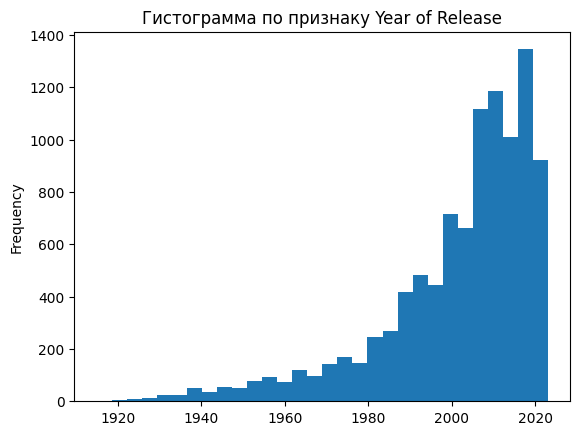

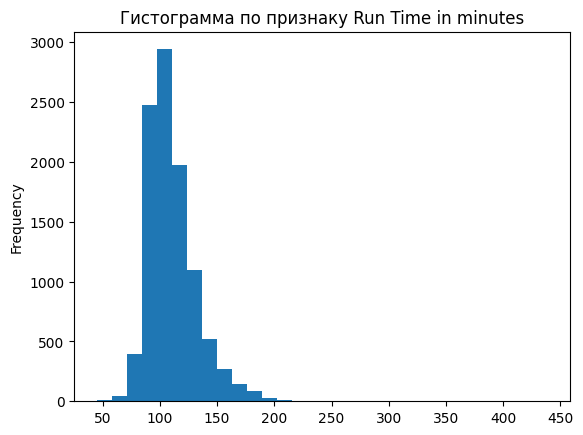

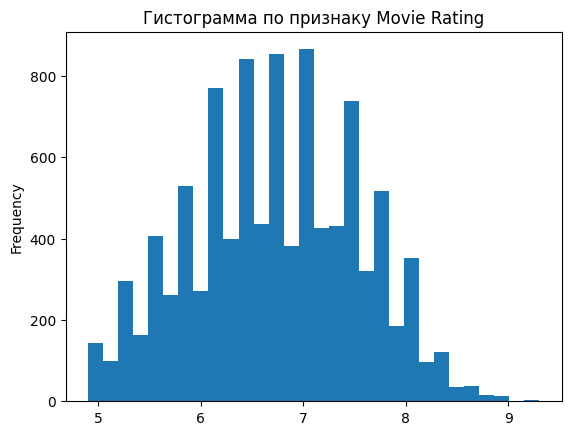

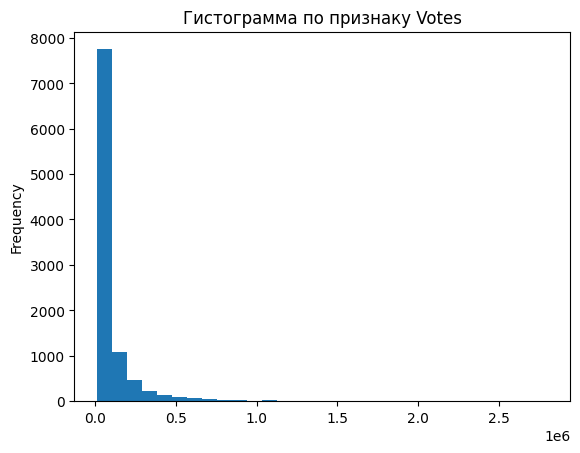

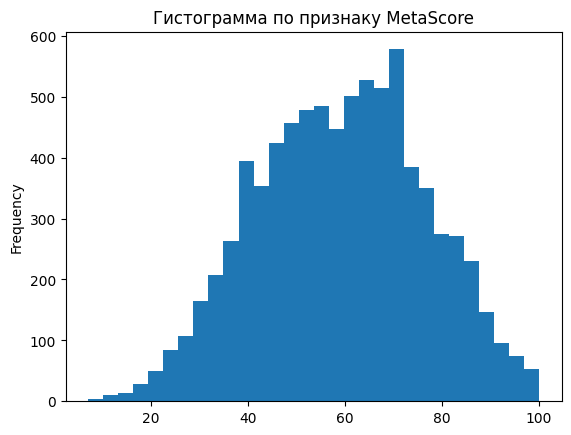

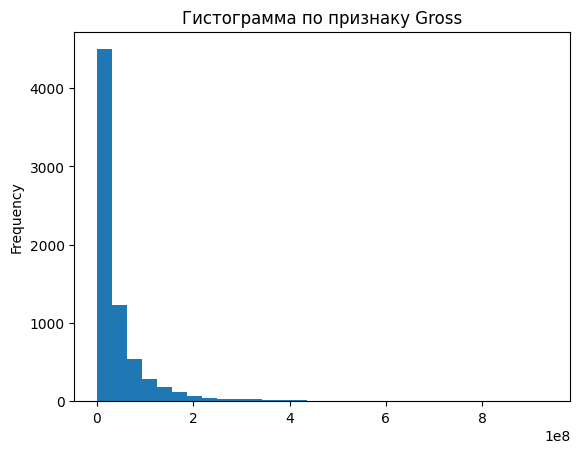

In [7]:
for i in df.columns:
    if df[i].dtype in ['int64', 'float64']:
        plt.figure()
        df[i].plot(kind='hist', title=f'Гистограмма по признаку {i}', bins=30)

Имеется сильная ассиметрия у рпризнаков votes и gross в правом хвосте. Логарифмируем и смотрим что произойдет. Заодно посмотрим что случится с другими фичами

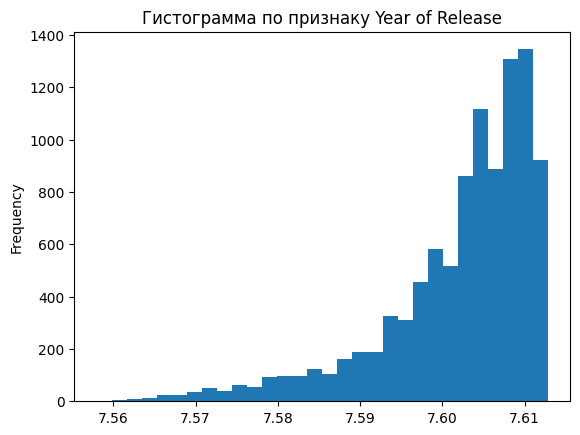

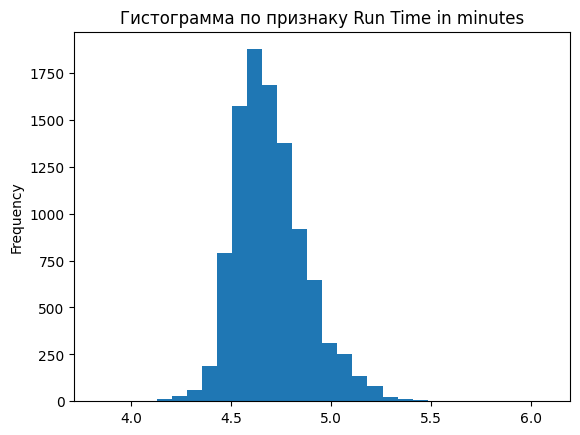

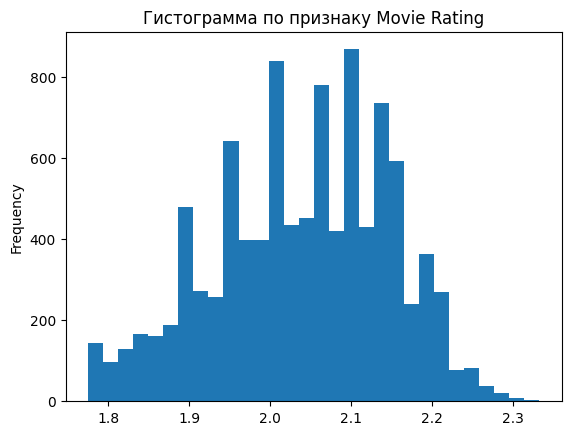

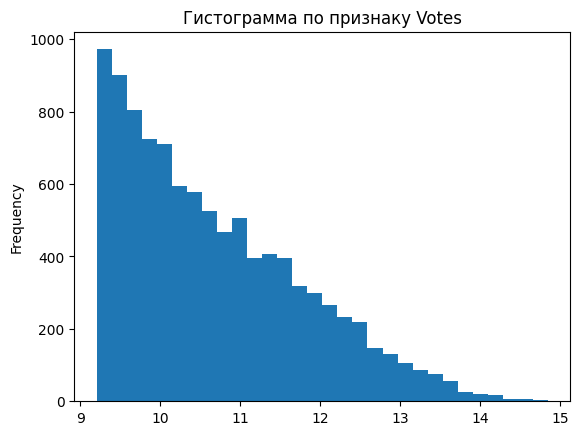

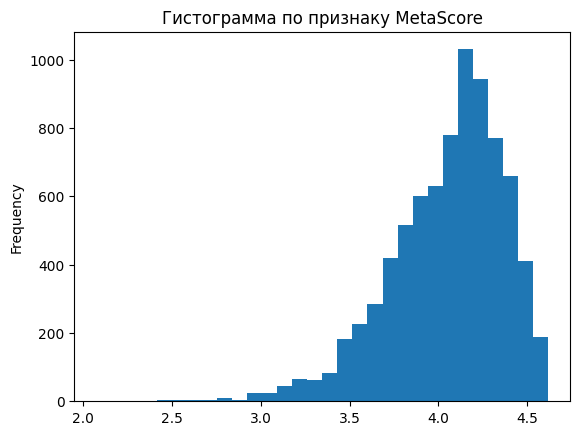

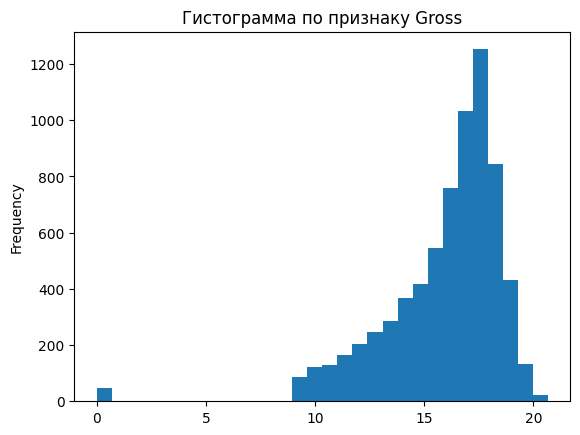

In [8]:
for i in df.columns:
    if df[i].dtype in ['int64', 'float64']:
        plt.figure()
        np.log1p(df[i]).plot(kind='hist', title=f'Гистограмма по признаку {i}', bins=30)

### создание новых признаков


In [9]:
split_col = lambda col: col.str.strip("[]").str.split(",").map(lambda lst: [x.strip(" '\"") for x in lst]) #1)скобки, 2)сплит по запятой 3) у каждого срезаем пробелы и кавычки

stars, dirs = split_col(df.Stars), split_col(df.Director)

top_actors = stars.explode().value_counts().head(20).index
top_directors = dirs.explode().value_counts().head(20).index

df = df.assign(
    log_votes=np.log1p(df.Votes),
    log_gross=np.log1p(df.Gross),
    genres_list=split_col(df.Genre),
    count_top_actors=stars.map(lambda s: sum(a in top_actors for a in s)),
    count_top_dirs=dirs.map(lambda s: sum(d in top_directors for d in s)),
    metascore_missing=df.MetaScore.isna().astype(int),
    gross_missing=df.Gross.isna().astype(int),
).assign(
    main_genre=lambda d: d.genres_list.str[0],        #первый в списке жанр будет главным
    count_genres=lambda d: d.genres_list.map(len),# колво жанров
    has_top_actor=lambda d: (d.count_top_actors > 0).astype(int), #бинарный
    has_top_dir=lambda d: (d.count_top_dirs > 0).astype(int), #бин
)
df

,Movie Name,Year of Release,Run Time in minutes,Movie Rating,Votes,MetaScore,Gross,Genre,Certification,Director,...,log_gross,genres_list,count_top_actors,count_top_dirs,metascore_missing,gross_missing,main_genre,count_genres,has_top_actor,has_top_dir
0,The Shawshank Redemption,1994,142,9.3,2804443,82.0,28340000.0,['Drama'],R,['Frank Darabont'],...,17.159785,[Drama],1,0,0,0,Drama,1,1,0
1,The Godfather,1972,175,9.2,1954174,100.0,134970000.0,"['Crime', ' Drama']",R,['Francis Ford Coppola'],...,18.720563,"[Crime, Drama]",0,0,0,0,Crime,2,0,0
2,Ramayana: The Legend of Prince Rama,1993,135,9.2,12995,NaN,NaN,"['Animation', ' Action', ' Adventure']",PG,"['Ram Mohan', 'Yûgô Sakô', 'Koichi Saski']",...,NaN,"[Animation, Action, Adventure]",0,0,1,1,Animation,3,0,0
3,The Chaos Class,1975,87,9.2,42231,NaN,NaN,"['Comedy', ' Drama']",NaN,['Ertem Egilmez'],...,NaN,"[Comedy, Drama]",0,0,1,1,Comedy,2,0,0
4,The Dark Knight,2008,152,9.0,2786129,84.0,534860000.0,"['Action', ' Crime', ' Drama']",PG-13,['Christopher Nolan'],...,20.097516,"[Action, Crime, Drama]",1,0,0,0,Action,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Golmaal Again,2017,140,4.9,10183,NaN,1010000.0,"['Action', ' Comedy', ' Fantasy']",Not Rated,['Rohit Shetty'],...,13.825462,"[Action, Comedy, Fantasy]",0,0,1,0,Action,3,0,0
9996,Not to Forget,2021,84,4.9,11191,NaN,NaN,['Drama'],NaN,['Valerio Zanoli'],...,NaN,[Drama],0,0,1,1,Drama,1,0,0
9997,Housefull 3,2016,140,4.9,10308,NaN,1160000.0,"['Action', ' Comedy', ' Romance']",Not Rated,"['Sajid', 'Farhad Samji']",...,13.963931,"[Action, Comedy, Romance]",1,0,1,0,Action,3,1,0
9998,A.I. Rising,2018,85,4.9,11187,NaN,NaN,"['Drama', ' Romance', ' Sci-Fi']",R,['Lazar Bodroza'],...,NaN,"[Drama, Romance, Sci-Fi]",0,0,1,1,Drama,3,0,0


### гистограмма и боксплот рейтинга

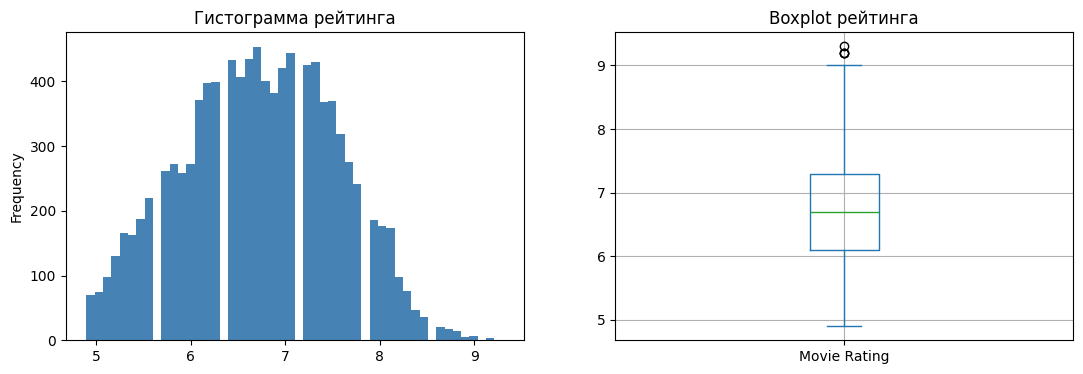

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['Movie Rating'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue',title='Гистограмма рейтинга')
df['Movie Rating'].plot(kind='box', ax=axes[1], title='Boxplot рейтинга', grid=1)

plt.show()

### фильмы и рейтинг по годам выпуска

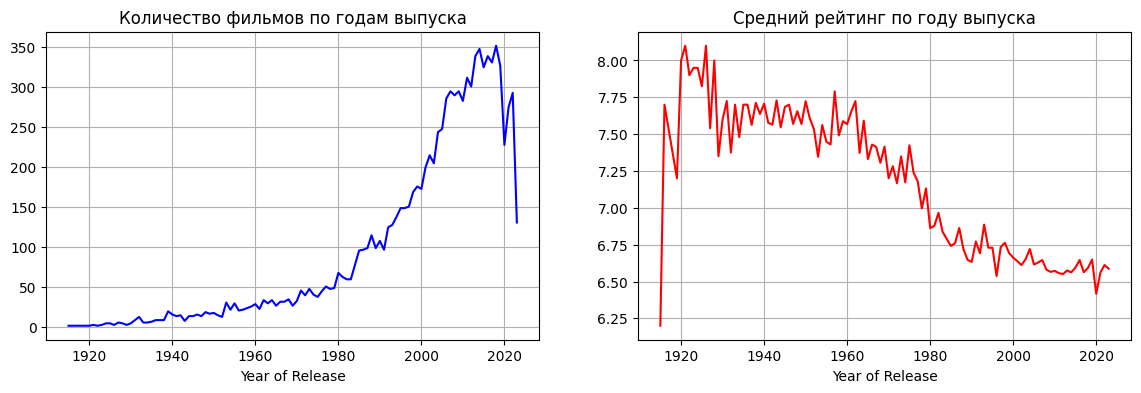

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('Year of Release').size().plot(ax=axes[0], color='blue', title='Количество фильмов по годам выпуска',grid=1)
df.groupby('Year of Release')['Movie Rating'].mean().plot(ax=axes[1], color='red', title='Средний рейтинг по году выпуска',grid=1)

plt.show()

### гистограммы числовыъ признаков

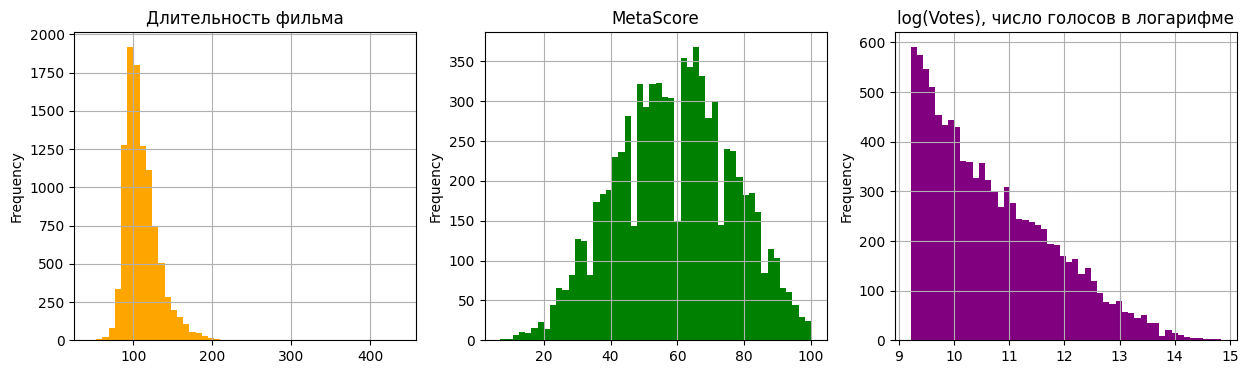

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Run Time in minutes'].plot(kind='hist', bins=50, ax=axes[0], color='orange',title='Длительность фильма',grid=1)
df['MetaScore'].plot(kind='hist', bins=50, ax=axes[1], color='green',title='MetaScore',grid=1)
df['log_votes'].plot(kind='hist', bins=50, ax=axes[2], color='purple',title='log(Votes), число голосов в логарифме',grid=1)

plt.show()

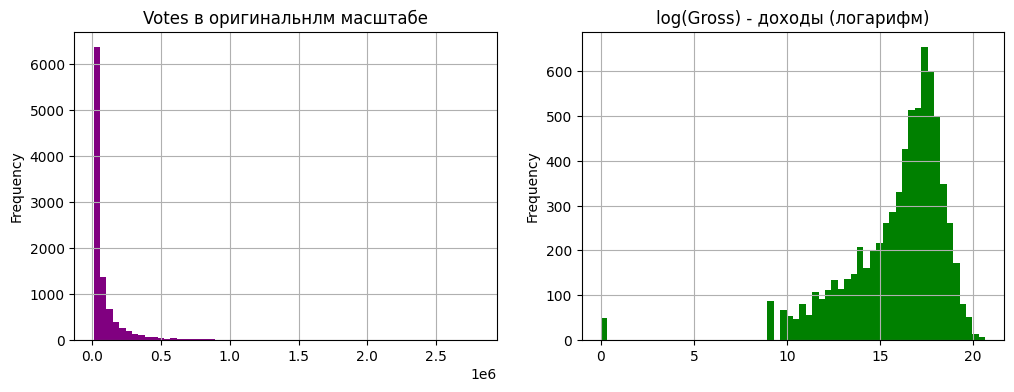

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Votes'].plot(kind='hist', bins=60, ax=axes[0], color='purple',title='Votes в оригинальнлм масштабе',grid=1)
df['log_gross'].plot(kind='hist', bins=60, ax=axes[1], color='green',title='log(Gross) - доходы (логарифм)',grid=1)

plt.show()

### 2.4 Корреляционный анализ

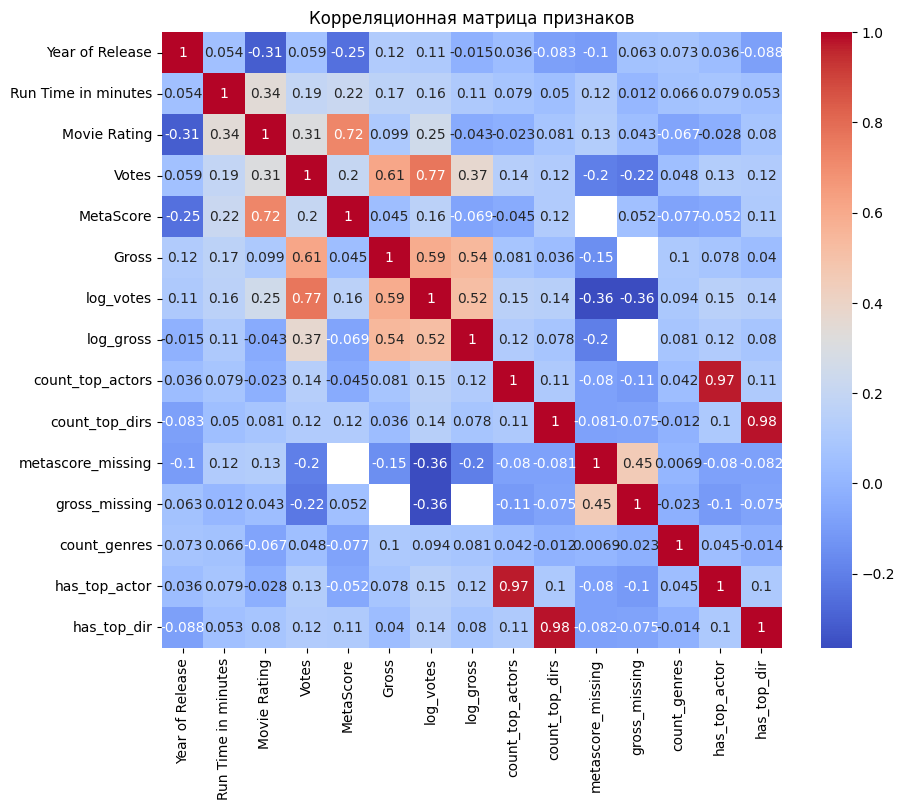

In [14]:

corr = df.corr(numeric_only=1)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

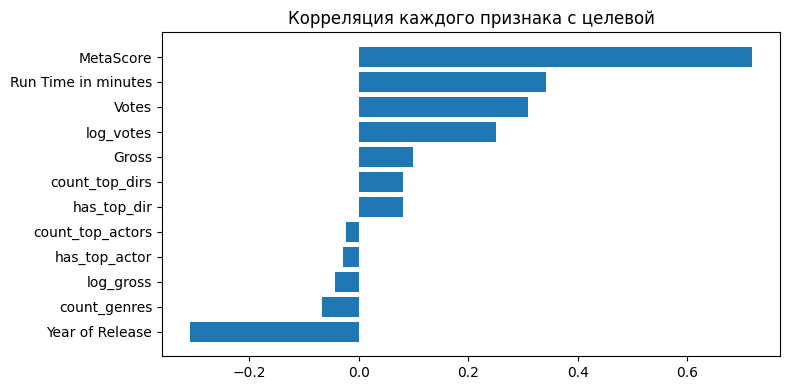

In [15]:
num_cols_corr = ['Year of Release', 'Run Time in minutes', 'MetaScore', 'Votes', 'Gross', 'Movie Rating', 'log_votes', 'log_gross', 'count_top_actors',
'count_top_dirs', 'count_genres', 'has_top_actor', 'has_top_dir']

target_corr = df[num_cols_corr].corr()['Movie Rating'].drop('Movie Rating').sort_values()

plt.figure(figsize=(8, 4))
plt.barh(target_corr.index, target_corr.values)
plt.title('Корреляция каждого признака с целевой')
plt.tight_layout()
plt.show()


### зрительский рейтинг по возрастному рейтингу

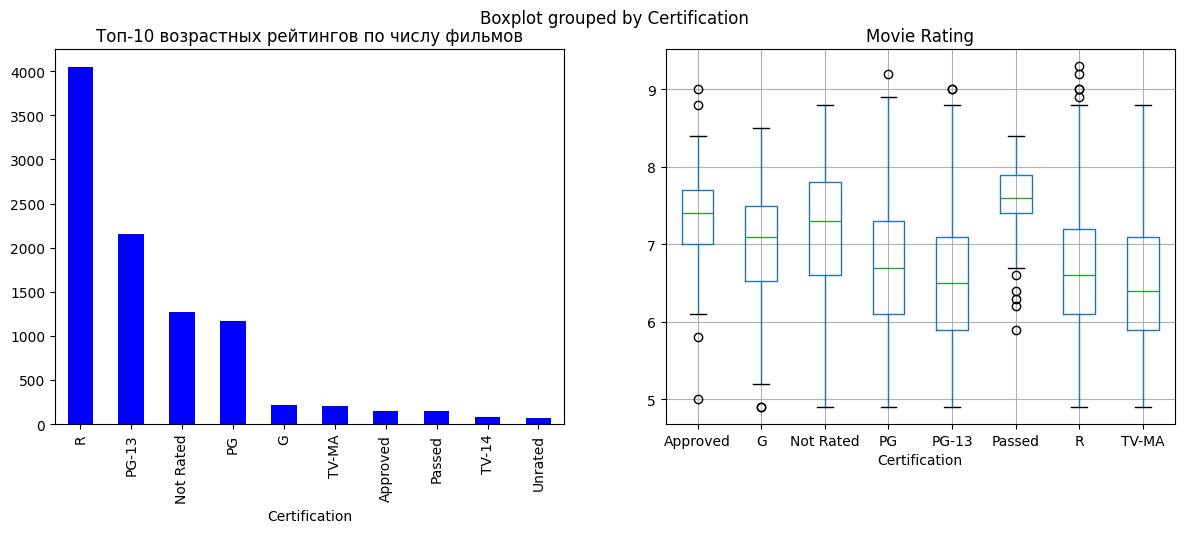

In [16]:
top_certs = df.Certification.value_counts().head(8).index
cert_data = df[df.Certification.isin(top_certs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.Certification.value_counts().head(10).plot(kind='bar', ax=axes[0], color='blue',title='Топ-10 возрастных рейтингов по числу фильмов')

cert_data.boxplot(column='Movie Rating', by='Certification', ax=axes[1])
plt.show()

### связь числовых признаков с рейтингом

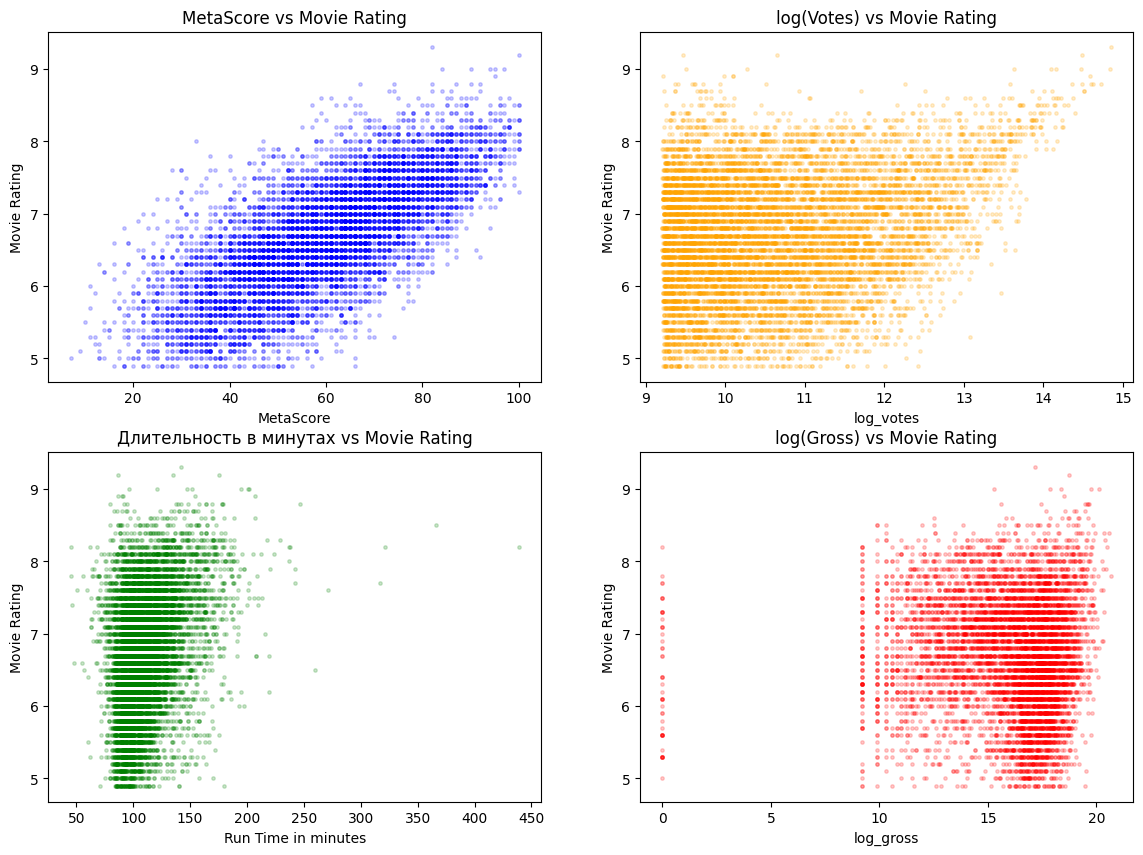

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.plot(kind='scatter', x='MetaScore', y='Movie Rating', alpha=0.2, s=6,ax=axes[0, 0], color='blue', title='MetaScore vs Movie Rating')
df.plot(kind='scatter', x='log_votes', y='Movie Rating', alpha=0.2, s=6,ax=axes[0, 1], color='orange', title='log(Votes) vs Movie Rating')
df.plot(kind='scatter', x='Run Time in minutes', y='Movie Rating', alpha=0.2, s=6,ax=axes[1, 0], color='green', title='Длительность в минутах vs Movie Rating')
df.plot(kind='scatter', x='log_gross', y='Movie Rating', alpha=0.2, s=6,ax=axes[1, 1], color='red', title='log(Gross) vs Movie Rating')

plt.show()

In [18]:
df

,Movie Name,Year of Release,Run Time in minutes,Movie Rating,Votes,MetaScore,Gross,Genre,Certification,Director,...,log_gross,genres_list,count_top_actors,count_top_dirs,metascore_missing,gross_missing,main_genre,count_genres,has_top_actor,has_top_dir
0,The Shawshank Redemption,1994,142,9.3,2804443,82.0,28340000.0,['Drama'],R,['Frank Darabont'],...,17.159785,[Drama],1,0,0,0,Drama,1,1,0
1,The Godfather,1972,175,9.2,1954174,100.0,134970000.0,"['Crime', ' Drama']",R,['Francis Ford Coppola'],...,18.720563,"[Crime, Drama]",0,0,0,0,Crime,2,0,0
2,Ramayana: The Legend of Prince Rama,1993,135,9.2,12995,NaN,NaN,"['Animation', ' Action', ' Adventure']",PG,"['Ram Mohan', 'Yûgô Sakô', 'Koichi Saski']",...,NaN,"[Animation, Action, Adventure]",0,0,1,1,Animation,3,0,0
3,The Chaos Class,1975,87,9.2,42231,NaN,NaN,"['Comedy', ' Drama']",NaN,['Ertem Egilmez'],...,NaN,"[Comedy, Drama]",0,0,1,1,Comedy,2,0,0
4,The Dark Knight,2008,152,9.0,2786129,84.0,534860000.0,"['Action', ' Crime', ' Drama']",PG-13,['Christopher Nolan'],...,20.097516,"[Action, Crime, Drama]",1,0,0,0,Action,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Golmaal Again,2017,140,4.9,10183,NaN,1010000.0,"['Action', ' Comedy', ' Fantasy']",Not Rated,['Rohit Shetty'],...,13.825462,"[Action, Comedy, Fantasy]",0,0,1,0,Action,3,0,0
9996,Not to Forget,2021,84,4.9,11191,NaN,NaN,['Drama'],NaN,['Valerio Zanoli'],...,NaN,[Drama],0,0,1,1,Drama,1,0,0
9997,Housefull 3,2016,140,4.9,10308,NaN,1160000.0,"['Action', ' Comedy', ' Romance']",Not Rated,"['Sajid', 'Farhad Samji']",...,13.963931,"[Action, Comedy, Romance]",1,0,1,0,Action,3,1,0
9998,A.I. Rising,2018,85,4.9,11187,NaN,NaN,"['Drama', ' Romance', ' Sci-Fi']",R,['Lazar Bodroza'],...,NaN,"[Drama, Romance, Sci-Fi]",0,0,1,1,Drama,3,0,0


In [19]:
data = df.assign(
    metascore=df.MetaScore.fillna(df.MetaScore.median()),
    log_gross=df.log_gross.fillna(df.log_gross.median()),
    cert=df.Certification.fillna('Unknown'),
    rating=df['Movie Rating'].astype(np.float32),
)

genre_dummies = pd.get_dummies(data.main_genre, prefix='genre')
cert_dummies  = pd.get_dummies(data.cert, prefix='cert')


num_cols = ['Year of Release', 'Run Time in minutes', 'log_votes', 'log_gross', 'metascore', 'count_top_actors', 'count_top_dirs', 'count_genres']
bin_cols = ['has_top_actor', 'has_top_dir', 'metascore_missing', 'gross_missing']
X = pd.concat([data[num_cols], data[bin_cols], genre_dummies, cert_dummies], axis=1).astype(np.float32)
y = data.rating


In [20]:
X

,Year of Release,Run Time in minutes,log_votes,log_gross,metascore,count_top_actors,count_top_dirs,count_genres,has_top_actor,has_top_dir,...,cert_TV-13,cert_TV-14,cert_TV-G,cert_TV-MA,cert_TV-PG,cert_TV-Y7,cert_TV-Y7-FV,cert_Unknown,cert_Unrated,cert_X
0,1994.0,142.0,14.846716,17.159784,82.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1972.0,175.0,14.485478,18.720564,100.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1993.0,135.0,9.472397,16.644598,60.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1975.0,87.0,10.650933,16.644598,60.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2008.0,152.0,14.840164,20.097515,84.0,1.0,0.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2017.0,140.0,9.228573,13.825462,60.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9996,2021.0,84.0,9.322954,16.644598,60.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9997,2016.0,140.0,9.240772,13.963931,60.0,1.0,0.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9998,2018.0,85.0,9.322598,16.644598,60.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
y

,rating
0,9.3
1,9.2
2,9.2
3,9.2
4,9.0
...,...
9995,4.9
9996,4.9
9997,4.9
9998,4.9


In [22]:
from sklearn.model_selection import train_test_split


In [23]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.18, random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler


In [25]:
import torch

In [26]:

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])



In [27]:
X_train_t = torch.tensor(X_train.values)
y_train_t = torch.tensor(y_train.values).reshape(-1, 1)
X_val_t   = torch.tensor(X_val.values)
y_val_t   = torch.tensor(y_val.values).reshape(-1, 1)
X_test_t  = torch.tensor(X_test.values)
y_test_t  = torch.tensor(y_test.values).reshape(-1, 1)

In [28]:
from torch.utils.data import DataLoader, TensorDataset


In [29]:
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

Настройка логгирования

In [30]:
with wandb.init(project='gp5_1path', name='Датасеты') as run:
    X_train.to_csv('X_train.csv', index=False)
    X_val.to_csv('X_val.csv',   index=False)
    X_test.to_csv('X_test.csv',  index=False)
    y_train.to_csv('y_train.csv', index=False)
    y_val.to_csv('y_val.csv',   index=False)
    y_test.to_csv('y_test.csv',  index=False)

    artifact = wandb.Artifact(
        type='dataset',
        name='datasets',
        description='train, val, test датасеты'
    )

    artifact.add_file('X_train.csv')
    artifact.add_file('X_val.csv')
    artifact.add_file('X_test.csv')
    artifact.add_file('y_train.csv')
    artifact.add_file('y_val.csv')
    artifact.add_file('y_test.csv')
    run.log_artifact(artifact)

Функция для обучения модели

In [31]:
import torch.nn as nn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [32]:
def train_and_log(model, name, params, epochs, lr, optimizer):
    torch.manual_seed(42)
    optimizer = optimizer(model.parameters(), lr=lr)
    loss_f = nn.MSELoss()
    train_losses, val_losses = [], []

    run = wandb.init(project='gp5_1path', name=name,
        config={
            **params,
            'epochs':            epochs,
            'lr':                lr,
            'batch_size':        256,
            'loss':              'MSELoss',
        })

    best_val_mse = 10**9

    for epoch in range(epochs):
        model.train()
        full_loss = 0

        for i, j in train_loader:
            optimizer.zero_grad()
            loss = loss_f(model(i), j)
            loss.backward()
            optimizer.step()
            full_loss += loss.item() * len(j)

        model.eval()
        with torch.no_grad():
            val_mse = loss_f(model(X_val_t), y_val_t).item()
        train_mse = full_loss / len(X_train_t)
        train_losses.append(train_mse)
        val_losses.append(val_mse)

        if val_mse < best_val_mse:
            best_val_mse = val_mse

        wandb.log({'train_mse': train_mse, 'val_mse': val_mse, 'epoch': epoch})

    model.eval()
    with torch.no_grad():
        pred = model(X_test_t).numpy().reshape(-1)

    metrics = {
        'test_rmse':       float(np.sqrt(mean_squared_error(y_test, pred))),
        'test_mae':        float(mean_absolute_error(y_test, pred)),
        'test_r2':         float(r2_score(y_test, pred)),

        'best_val_mse':    best_val_mse,
        'best_val_rmse':   float(np.sqrt(best_val_mse)),

        'final_train_mse': train_losses[-1],
        'final_val_mse':   val_losses[-1],
    }

    wandb.log(metrics)
    model_path = f'{name}_model.pth'

    torch.save(model.state_dict(), model_path)

    artifact = wandb.Artifact(
        name=name,
        type='model',
        description=(
            f'arch={params.get("arch","")}'
            f'activation = {params.get("activation","")}'
            f'regularization = {params.get("regularization","")}'
            f'optimizer = {params.get("optimizer","")}'
        ),
        metadata={
            'test_rmse':   metrics['test_rmse'],
            'test_mae':    metrics['test_mae'],
            'test_r2':     metrics['test_r2'],
        }
    )

    artifact.add_file(model_path)
    wandb.log_artifact(artifact)
    wandb.finish()

    print(f"{name}: модель обучена")
    return metrics, (train_losses, val_losses)


results = {}
pair_losses  = {}

Обучаем 4 конфигурации модели

1. Мелкая сеть с ReLu

In [34]:
model1 = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 1))

res = train_and_log(model1, '1_small_model_64_1', {'arch': '64_ReLu_1', 'activation': 'ReLU', 'regularization': 'нет', 'optimizer': 'Adam'},epochs = 100, lr = 0.001, optimizer = torch.optim.Adam)

results['1: Мелкая сеть с ReLu'], pair_losses['1: Мелкая сеть с ReLu'] = res[0], res[1]

best_val_mse,▁
best_val_rmse,▁
epoch,▁▁▁▁▁▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
final_train_mse,▁
final_val_mse,▁
test_mae,▁
test_r2,▁
test_rmse,▁
train_mse,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mse,█▆▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_mse,0.24015


1_small_model_64_1: модель обучена


2. Глубокая сеть с ReLu

In [35]:
model2 = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)
res = train_and_log(model2, '2_deep_model_256_128_64', {'arch': '256_ReLu_128_ReLu_64_ReLu', 'activation': 'ReLU', 'regularization': 'нет', 'optimizer': 'Adam'},epochs = 100, lr = 0.001, optimizer = torch.optim.Adam)

results['2: Глубокая сеть с ReLu'], pair_losses['2: Глубокая сеть с ReLu'] = res[0], res[1]

best_val_mse,▁
best_val_rmse,▁
epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
final_train_mse,▁
final_val_mse,▁
test_mae,▁
test_r2,▁
test_rmse,▁
train_mse,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mse,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_mse,0.23194


2_deep_model_256_128_64: модель обучена


3. Глубокая сеть с регуляризацией

In [36]:
model3 = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

res = train_and_log(model3, '3_deep_model_256_Drop_128_Drop_64', {'arch': '256_ReLu_Dropout_128_ReLu_Dropout_64_ReLu', 'activation': 'ReLU', 'regularization': 'Dropout 0.3', 'optimizer': 'Adam'},epochs = 100, lr = 0.001, optimizer = torch.optim.Adam)

results['3: Глубокая сеть с ReLu и регуляризацией'], pair_losses['3: Глубокая сеть с ReLu и регуляризацией'] = res[0], res[1]

best_val_mse,▁
best_val_rmse,▁
epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇█
final_train_mse,▁
final_val_mse,▁
test_mae,▁
test_r2,▁
test_rmse,▁
train_mse,█▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mse,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_mse,0.23067


3_deep_model_256_Drop_128_Drop_64: модель обучена


4. GELU + AdamW

In [37]:
model4 = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 256),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.GELU(),
    nn.Linear(64, 1)
)

res = train_and_log(model4, '4_deep_model_256_Drop_128_Drop_64_GeLu', {'arch': '256_GeLu_Dropout_128_GeLu_Dropout_64_GeLu', 'activation': 'GeLU', 'regularization': 'Dropout 0.3', 'optimizer': 'AdamW'},epochs = 100, lr = 0.001, optimizer = torch.optim.AdamW)

results['4: Глубокая сеть с AdamW, GeLu и регуляризацией'], pair_losses['4: Глубокая сеть с AdamW, GeLu и регуляризацией'] = res[0], res[1]

best_val_mse,▁
best_val_rmse,▁
epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇███
final_train_mse,▁
final_val_mse,▁
test_mae,▁
test_r2,▁
test_rmse,▁
train_mse,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mse,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_mse,0.23338


4_deep_model_256_Drop_128_Drop_64: модель обучена


Итоговые выводы

In [38]:
base_rmse = float(np.sqrt(mean_squared_error(y_test, np.full(len(y_test), y_train.mean()))))
print(f'Прогнозирование средним: RMSE = {base_rmse:}')
print()
res = pd.DataFrame(results).T
res

Прогнозирование средним: RMSE = 0.8271123344532026



,test_rmse,test_mae,test_r2,best_val_mse,best_val_rmse,final_train_mse,final_val_mse
1: Мелкая сеть с ReLu,0.466231,0.358126,0.682104,0.240151,0.490052,0.214137,0.243211
2: Глубокая сеть с ReLu,0.480429,0.372995,0.662448,0.231935,0.481597,0.165484,0.250792
3: Глубокая сеть с ReLu и регуляризацией,0.460131,0.352871,0.690369,0.230667,0.480278,0.249200,0.230667
"4: Глубокая сеть с AdamW, GeLu и регуляризацией",0.468582,0.359170,0.678890,0.233385,0.483099,0.267612,0.233385
